# Chitosan Water Treatment Parameter Optimization
Machine Learning model to predict optimal treatment parameters based on water quality and desired performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_excel('Chitosan_Realistic_Dataset.xlsx')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (500, 9)


,Rapid mixing rate (rpm),Colour removal (%),Turbidity removal (%),Coagulant volume (mL),Rapid mixing time (min),TDS,DO,pH,Nitrate
0,152,80.784503,86.526519,247.612924,3.805499,398.863286,3.848585,7.387406,31.127458
1,229,75.015608,87.275975,43.620164,3.236402,559.277530,3.098493,6.872564,23.438327
2,142,83.468919,87.220783,134.399117,7.695517,476.355500,2.740915,7.078435,22.087060
3,64,77.542826,79.688285,220.569537,1.301792,469.245779,2.895984,6.580155,20.856034
4,156,76.943397,84.122395,187.784468,6.129007,450.656022,2.965613,7.216445,26.773538


In [2]:
print("Dataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rapid mixing rate (rpm)  500 non-null    int64  
 1   Colour removal (%)       500 non-null    float64
 2   Turbidity removal (%)    500 non-null    float64
 3   Coagulant volume (mL)    500 non-null    float64
 4   Rapid mixing time (min)  500 non-null    float64
 5   TDS                      500 non-null    float64
 6   DO                       500 non-null    float64
 7   pH                       500 non-null    float64
 8   Nitrate                  500 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 35.3 KB
None

Statistical Summary:
       Rapid mixing rate (rpm)  Colour removal (%)  Turbidity removal (%)  \
count               500.000000          500.000000             500.000000   
mean                178.626000           80.65234

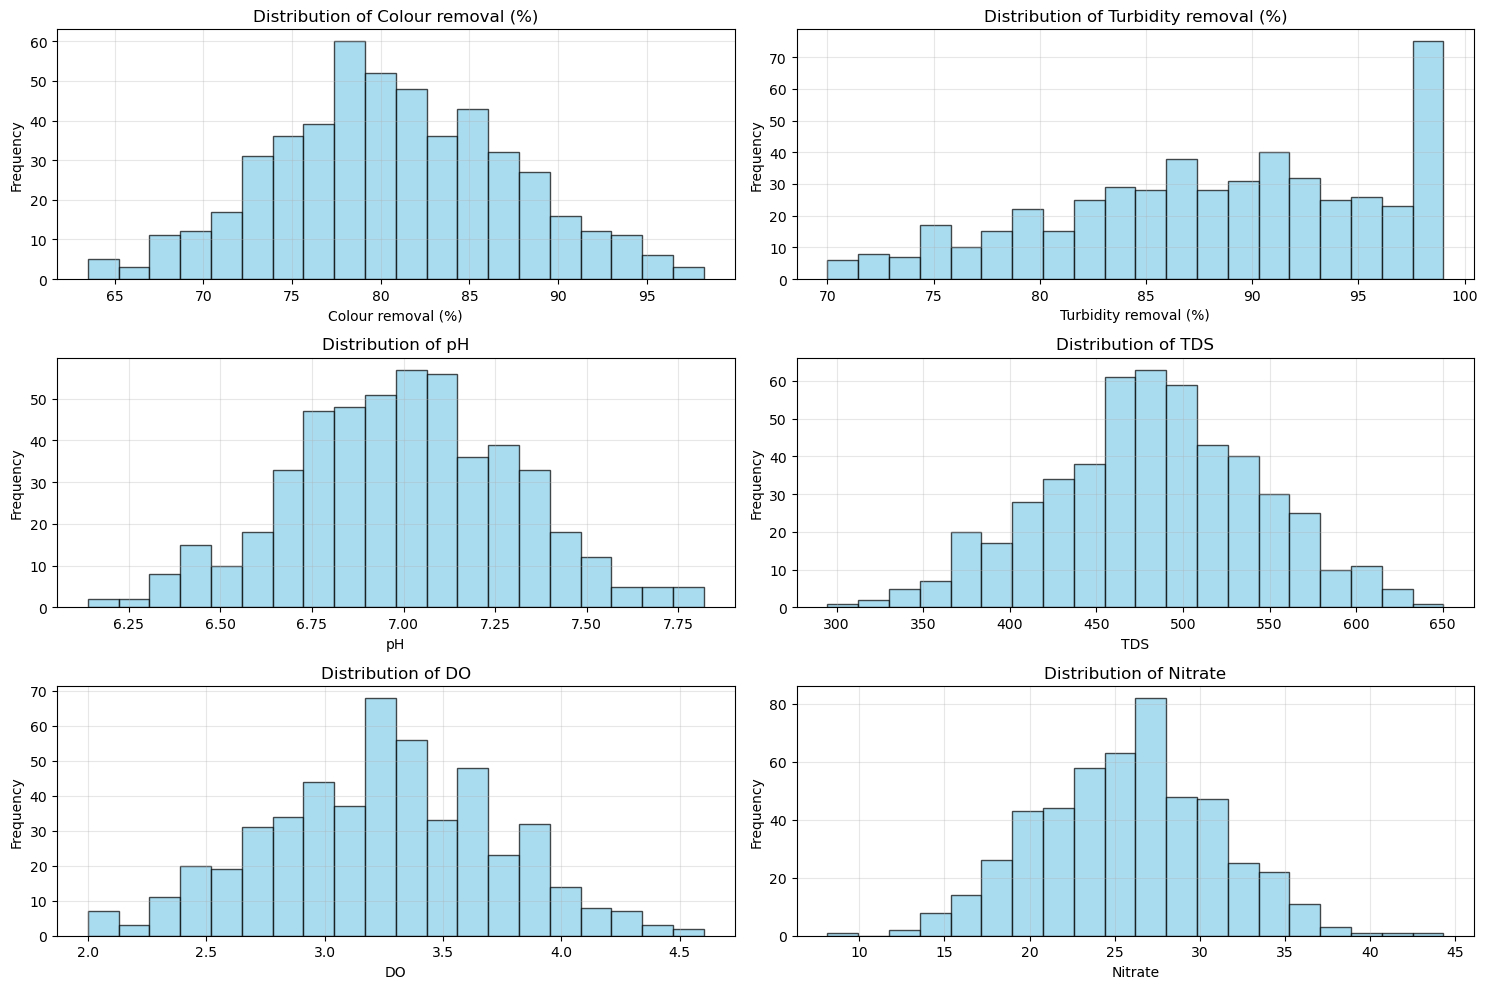

In [3]:
plt.figure(figsize=(15, 10))

variables = ['Colour removal (%)', 'Turbidity removal (%)', 'pH', 'TDS', 'DO', 'Nitrate']

for i, var in enumerate(variables, 1):
    plt.subplot(3, 2, i)
    plt.hist(df[var], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

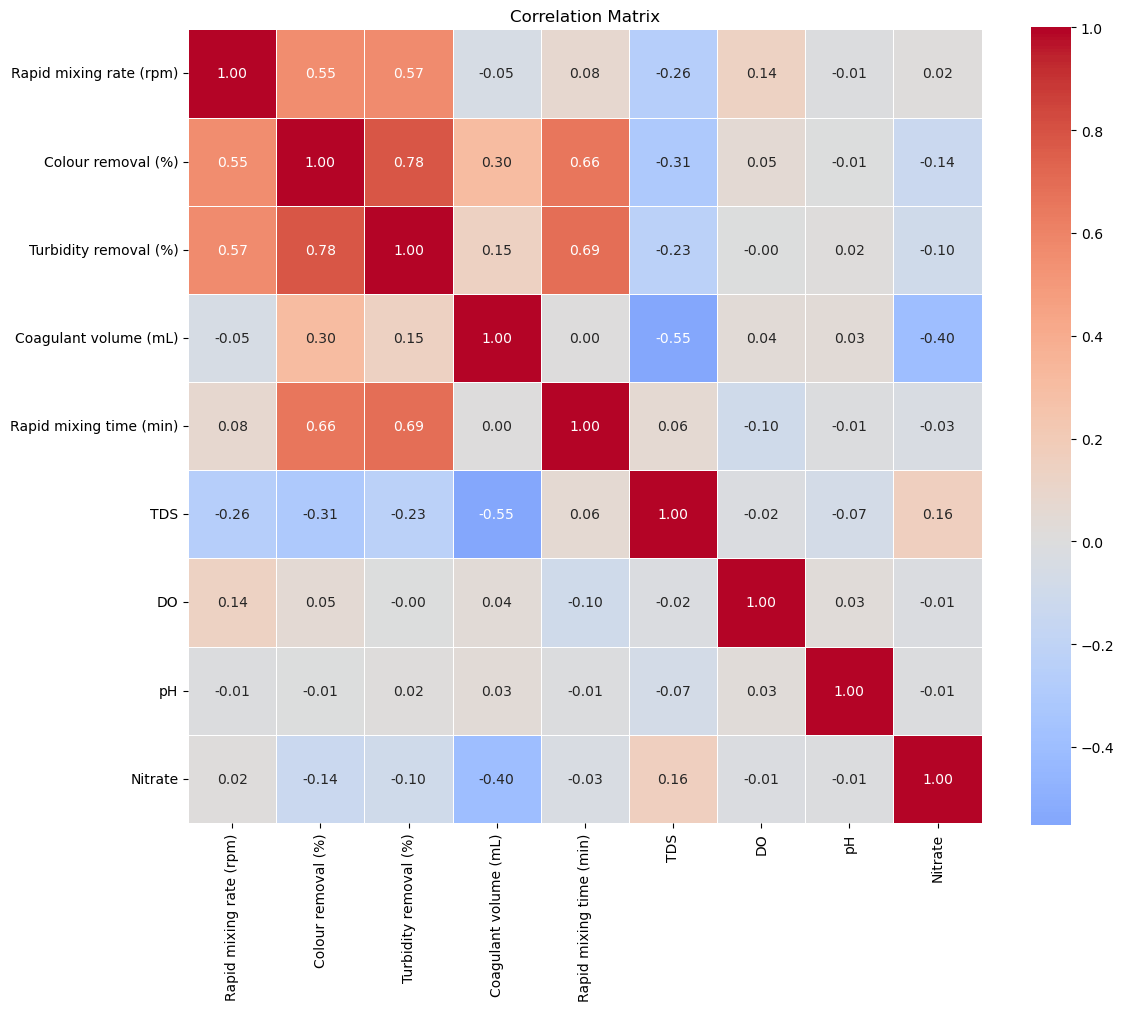

In [4]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

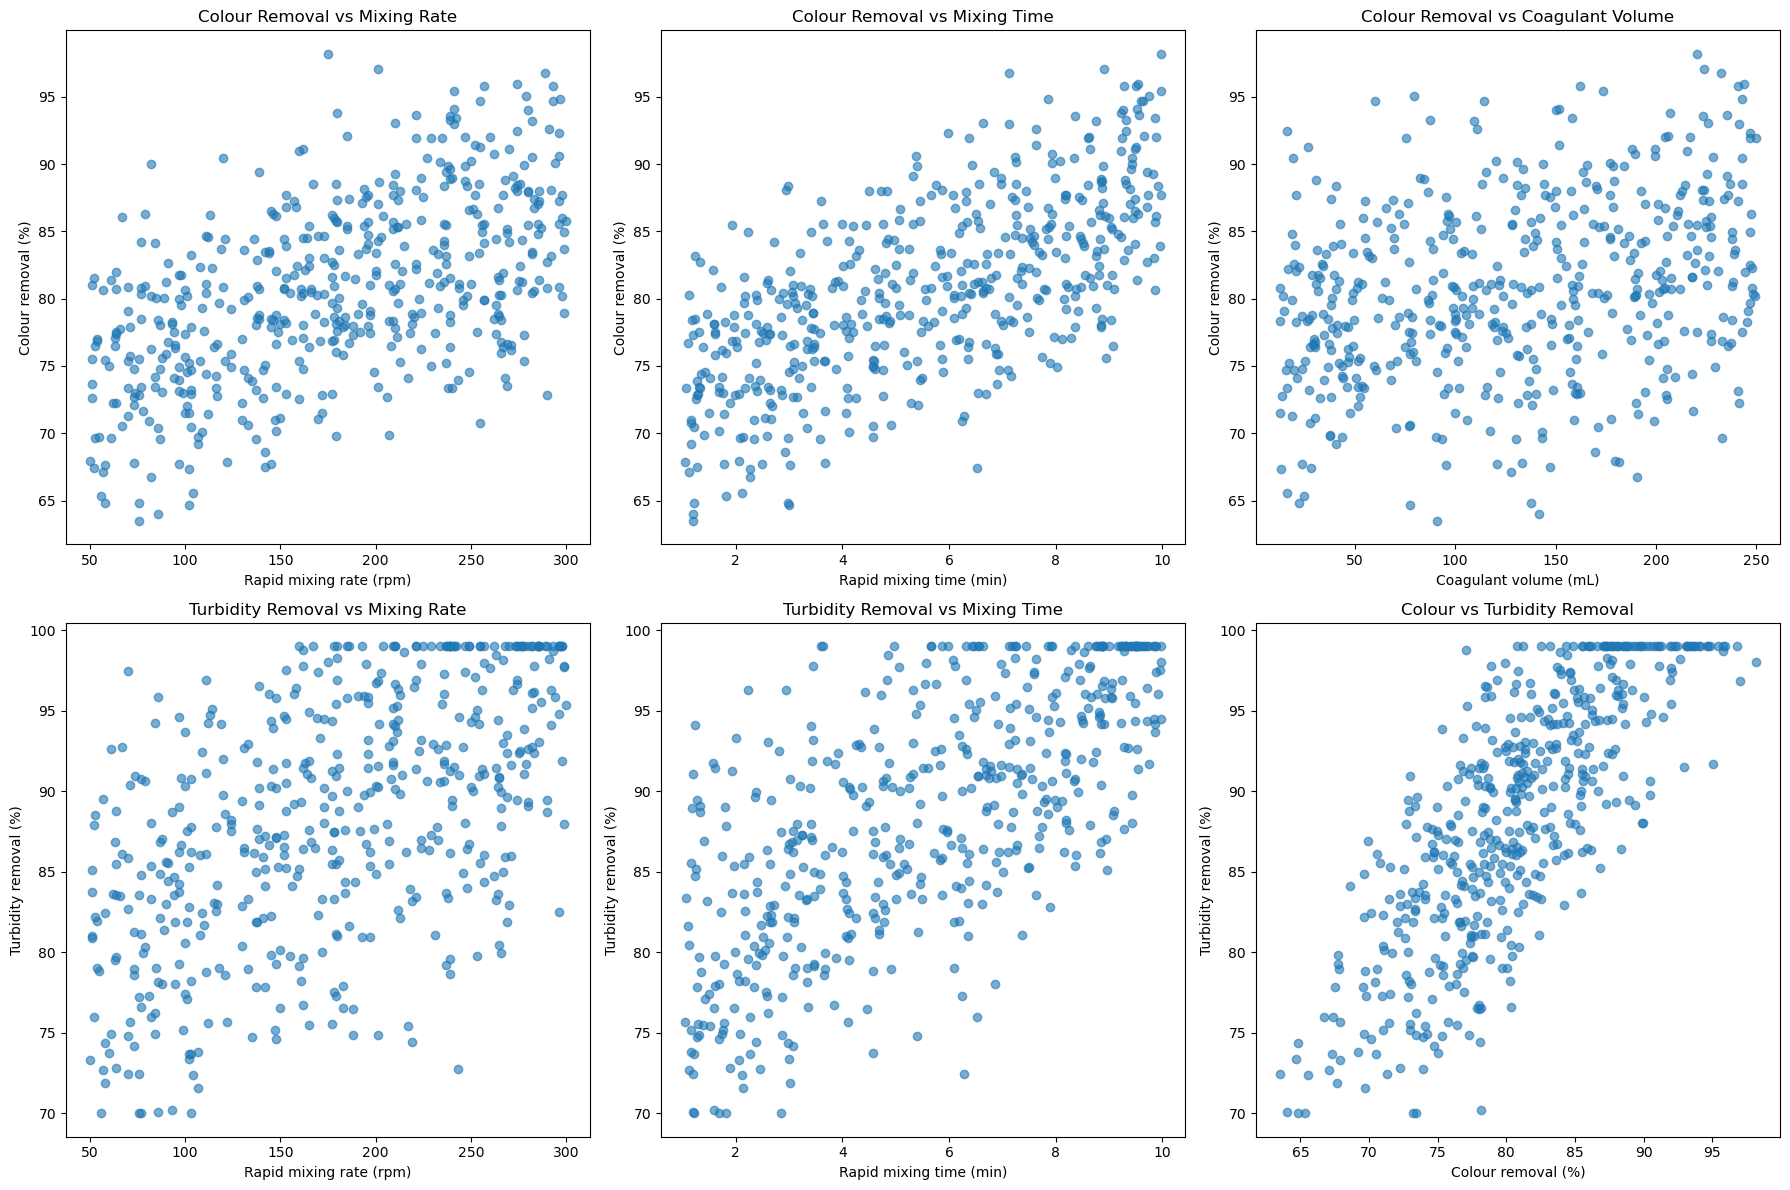

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].scatter(df['Rapid mixing rate (rpm)'], df['Colour removal (%)'], alpha=0.6)
axes[0, 0].set_xlabel('Rapid mixing rate (rpm)')
axes[0, 0].set_ylabel('Colour removal (%)')
axes[0, 0].set_title('Colour Removal vs Mixing Rate')

axes[0, 1].scatter(df['Rapid mixing time (min)'], df['Colour removal (%)'], alpha=0.6)
axes[0, 1].set_xlabel('Rapid mixing time (min)')
axes[0, 1].set_ylabel('Colour removal (%)')
axes[0, 1].set_title('Colour Removal vs Mixing Time')

axes[0, 2].scatter(df['Coagulant volume (mL)'], df['Colour removal (%)'], alpha=0.6)
axes[0, 2].set_xlabel('Coagulant volume (mL)')
axes[0, 2].set_ylabel('Colour removal (%)')
axes[0, 2].set_title('Colour Removal vs Coagulant Volume')

axes[1, 0].scatter(df['Rapid mixing rate (rpm)'], df['Turbidity removal (%)'], alpha=0.6)
axes[1, 0].set_xlabel('Rapid mixing rate (rpm)')
axes[1, 0].set_ylabel('Turbidity removal (%)')
axes[1, 0].set_title('Turbidity Removal vs Mixing Rate')

axes[1, 1].scatter(df['Rapid mixing time (min)'], df['Turbidity removal (%)'], alpha=0.6)
axes[1, 1].set_xlabel('Rapid mixing time (min)')
axes[1, 1].set_ylabel('Turbidity removal (%)')
axes[1, 1].set_title('Turbidity Removal vs Mixing Time')

axes[1, 2].scatter(df['Colour removal (%)'], df['Turbidity removal (%)'], alpha=0.6)
axes[1, 2].set_xlabel('Colour removal (%)')
axes[1, 2].set_ylabel('Turbidity removal (%)')
axes[1, 2].set_title('Colour vs Turbidity Removal')

plt.tight_layout()
plt.show()

## Machine Learning Model

In [6]:
if 'Coagulant concentration (mg/L)' not in df.columns:
    df['Coagulant concentration (mg/L)'] = df['Coagulant volume (mL)'] * 2.5

X = df[['pH', 'DO', 'Nitrate', 'TDS', 'Colour removal (%)', 'Turbidity removal (%)']]
y = df[['Rapid mixing rate (rpm)', 'Rapid mixing time (min)', 'Coagulant volume (mL)', 'Coagulant concentration (mg/L)']]

print(f"Input features: {list(X.columns)}")
print(f"Target variables: {list(y.columns)}")
print(f"Dataset shape: X={X.shape}, y={y.shape}")

Input features: ['pH', 'DO', 'Nitrate', 'TDS', 'Colour removal (%)', 'Turbidity removal (%)']
Target variables: ['Rapid mixing rate (rpm)', 'Rapid mixing time (min)', 'Coagulant volume (mL)', 'Coagulant concentration (mg/L)']
Dataset shape: X=(500, 6), y=(500, 4)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 400 samples
Test set: 100 samples


In [8]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Multi-RF': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    if name == 'Random Forest':
        model.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    target_metrics = {}
    for i, target in enumerate(y.columns):
        mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        
        target_metrics[target] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}
    
    results[name] = {'predictions': y_pred, 'metrics': target_metrics, 'model': model}
    print(f"  {name} trained successfully!")

print("\nTraining completed!")

Training Random Forest...
  Random Forest trained successfully!
Training Multi-RF...
  Multi-RF trained successfully!

Training completed!


In [9]:
comparison_data = []
for model_name, result in results.items():
    for target, metrics in result['metrics'].items():
        comparison_data.append({
            'Model': model_name,
            'Target Variable': target,
            'R²': f"{metrics['R²']:.3f}",
            'RMSE': f"{metrics['RMSE']:.2f}",
            'MAE': f"{metrics['MAE']:.2f}"
        })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

avg_r2_scores = {}
for model_name, result in results.items():
    r2_scores = [metrics['R²'] for metrics in result['metrics'].values()]
    avg_r2_scores[model_name] = np.mean(r2_scores)

best_model_name = max(avg_r2_scores.items(), key=lambda x: x[1])[0]
best_model = results[best_model_name]['model']

print(f"\nBest Model: {best_model_name}")
print(f"Average R² Score: {avg_r2_scores[best_model_name]:.3f}")


Model Performance Comparison:
        Model                Target Variable    R²   RMSE    MAE
Random Forest        Rapid mixing rate (rpm) 0.311  56.78  46.56
Random Forest        Rapid mixing time (min) 0.403   1.98   1.60
Random Forest          Coagulant volume (mL) 0.357  56.94  47.00
Random Forest Coagulant concentration (mg/L) 0.357 142.36 117.50
     Multi-RF        Rapid mixing rate (rpm) 0.303  57.13  47.33
     Multi-RF        Rapid mixing time (min) 0.417   1.95   1.53
     Multi-RF          Coagulant volume (mL) 0.378  56.01  45.39
     Multi-RF Coagulant concentration (mg/L) 0.380 139.85 113.09

Best Model: Multi-RF
Average R² Score: 0.369



Feature Importance:
              Feature  Importance
                  TDS    0.276874
Turbidity removal (%)    0.221273
   Colour removal (%)    0.179570
              Nitrate    0.148135
                   DO    0.101165
                   pH    0.072983


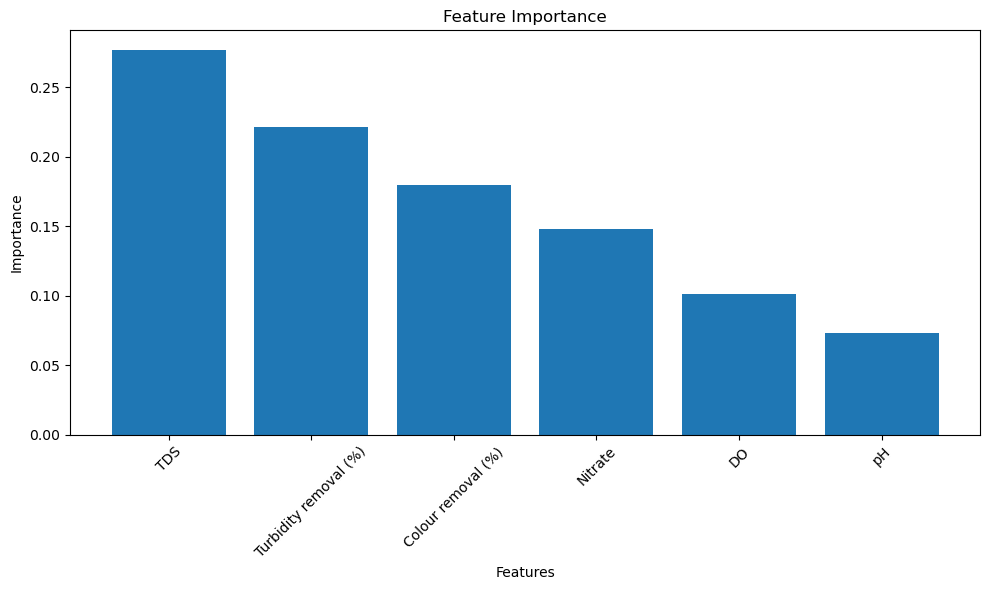

In [10]:
if hasattr(best_model, 'estimators_'):
    feature_importance_matrix = []
    for estimator in best_model.estimators_:
        feature_importance_matrix.append(estimator.feature_importances_)
    
    feature_importance = np.mean(feature_importance_matrix, axis=0)
    
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.bar(importance_df['Feature'], importance_df['Importance'])
    plt.title('Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Prediction Function

In [11]:
def predict_optimal_parameters(pH, DO, nitrate, TDS, desired_colour_removal, desired_turbidity_removal):
    """
    Predict optimal chitosan treatment parameters.
    
    Parameters:
    - pH: Water pH level (6.0-8.0)
    - DO: Dissolved Oxygen (1.0-6.0 mg/L)
    - nitrate: Nitrate concentration (5-60 mg/L)
    - TDS: Total Dissolved Solids (200-700 mg/L)
    - desired_colour_removal: Target colour removal (60-100%)
    - desired_turbidity_removal: Target turbidity removal (70-100%)
    
    Returns:
    - Dictionary with predicted optimal parameters
    """
    input_data = np.array([[pH, DO, nitrate, TDS, desired_colour_removal, desired_turbidity_removal]])
    input_scaled = scaler_X.transform(input_data)
    
    if best_model_name == 'Random Forest':
        prediction_scaled = best_model.predict(input_scaled)
        prediction = scaler_y.inverse_transform(prediction_scaled)
    else:
        prediction = best_model.predict(input_scaled)
    
    rapid_mixing_rate = np.clip(prediction[0][0], 50, 300)
    rapid_mixing_time = np.clip(prediction[0][1], 1, 10)
    coagulant_volume = np.clip(prediction[0][2], 12, 250)
    coagulant_concentration = np.clip(prediction[0][3], 30, 625)
    
    return {
        'Rapid mixing rate (rpm)': round(rapid_mixing_rate, 1),
        'Rapid mixing time (min)': round(rapid_mixing_time, 2),
        'Coagulant volume (mL)': round(coagulant_volume, 1),
        'Coagulant concentration (mg/L)': round(coagulant_concentration, 1)
    }

print("Prediction function created successfully!")

Prediction function created successfully!


## Model Testing

In [12]:
test_scenarios = [
    {'name': 'High Performance', 'pH': 7.0, 'DO': 3.5, 'nitrate': 25.0, 'TDS': 400.0, 
     'colour': 95.0, 'turbidity': 98.0},
    {'name': 'Moderate Performance', 'pH': 6.8, 'DO': 3.0, 'nitrate': 30.0, 'TDS': 450.0,
     'colour': 85.0, 'turbidity': 90.0},
    {'name': 'Standard Treatment', 'pH': 7.2, 'DO': 3.8, 'nitrate': 22.0, 'TDS': 380.0,
     'colour': 90.0, 'turbidity': 95.0}
]

for scenario in test_scenarios:
    print(f"\n{scenario['name']}:")
    print(f"  Water: pH={scenario['pH']}, DO={scenario['DO']}, Nitrate={scenario['nitrate']}, TDS={scenario['TDS']}")
    print(f"  Target: {scenario['colour']}% colour, {scenario['turbidity']}% turbidity")
    
    result = predict_optimal_parameters(
        scenario['pH'], scenario['DO'], scenario['nitrate'], scenario['TDS'],
        scenario['colour'], scenario['turbidity']
    )
    
    print(f"  Recommended:")
    for param, value in result.items():
        print(f"    • {param}: {value}")


High Performance:
  Water: pH=7.0, DO=3.5, Nitrate=25.0, TDS=400.0
  Target: 95.0% colour, 98.0% turbidity
  Recommended:
    • Rapid mixing rate (rpm): 118.2
    • Rapid mixing time (min): 2.23
    • Coagulant volume (mL): 194.7
    • Coagulant concentration (mg/L): 485.6

Moderate Performance:
  Water: pH=6.8, DO=3.0, Nitrate=30.0, TDS=450.0
  Target: 85.0% colour, 90.0% turbidity
  Recommended:
    • Rapid mixing rate (rpm): 118.2
    • Rapid mixing time (min): 2.23
    • Coagulant volume (mL): 194.7
    • Coagulant concentration (mg/L): 485.6

Standard Treatment:
  Water: pH=7.2, DO=3.8, Nitrate=22.0, TDS=380.0
  Target: 90.0% colour, 95.0% turbidity
  Recommended:
    • Rapid mixing rate (rpm): 118.2
    • Rapid mixing time (min): 2.23
    • Coagulant volume (mL): 194.7
    • Coagulant concentration (mg/L): 485.6


c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\User

## Model Validation

In [13]:
if best_model_name == 'Random Forest':
    test_predictions_scaled = best_model.predict(X_test_scaled)
    test_predictions = scaler_y.inverse_transform(test_predictions_scaled)
else:
    test_predictions = best_model.predict(X_test)

print("Sample Predictions vs Actual (first 5 test samples):")
for i in range(min(5, len(y_test))):
    actual = y_test.iloc[i].values
    predicted = test_predictions[i]
    
    print(f"\nSample {i+1}:")
    for j, col in enumerate(y.columns):
        print(f"  {col}: {actual[j]:.1f} → {predicted[j]:.1f}")

Sample Predictions vs Actual (first 5 test samples):

Sample 1:
  Rapid mixing rate (rpm): 109.0 → 207.7
  Rapid mixing time (min): 8.8 → 5.0
  Coagulant volume (mL): 98.9 → 121.2
  Coagulant concentration (mg/L): 247.3 → 307.4

Sample 2:
  Rapid mixing rate (rpm): 133.0 → 123.4
  Rapid mixing time (min): 5.5 → 5.0
  Coagulant volume (mL): 21.0 → 74.2
  Coagulant concentration (mg/L): 52.6 → 186.2

Sample 3:
  Rapid mixing rate (rpm): 148.0 → 100.5
  Rapid mixing time (min): 1.7 → 2.3
  Coagulant volume (mL): 117.4 → 129.5
  Coagulant concentration (mg/L): 293.4 → 333.6

Sample 4:
  Rapid mixing rate (rpm): 121.0 → 110.9
  Rapid mixing time (min): 3.7 → 2.5
  Coagulant volume (mL): 80.4 → 128.5
  Coagulant concentration (mg/L): 200.9 → 322.7

Sample 5:
  Rapid mixing rate (rpm): 144.0 → 178.0
  Rapid mixing time (min): 6.0 → 6.2
  Coagulant volume (mL): 102.7 → 124.7
  Coagulant concentration (mg/L): 256.7 → 311.6


## Interactive Prediction System

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output

w_pH = widgets.FloatSlider(value=7.0, min=6.0, max=8.0, step=0.1, description='pH:', readout_format='.1f')
w_DO = widgets.FloatSlider(value=3.5, min=1.0, max=6.0, step=0.1, description='DO (mg/L):', readout_format='.1f')
w_nitrate = widgets.FloatSlider(value=25.0, min=5.0, max=60.0, step=1.0, description='Nitrate:', readout_format='.1f')
w_TDS = widgets.FloatSlider(value=400.0, min=200.0, max=700.0, step=10.0, description='TDS (mg/L):', readout_format='.0f')
w_colour = widgets.FloatSlider(value=90.0, min=60.0, max=100.0, step=1.0, description='Target Colour %:', readout_format='.0f', style={'description_width': 'initial'})
w_turbidity = widgets.FloatSlider(value=95.0, min=70.0, max=100.0, step=1.0, description='Target Turbidity %:', readout_format='.0f', style={'description_width': 'initial'})

btn_predict = widgets.Button(description="Optimize Parameters", button_style='success', icon='check')
output_area = widgets.Output()

def on_predict_click(b):
    with output_area:
        clear_output()
        
        result = predict_optimal_parameters(
            pH=w_pH.value,
            DO=w_DO.value,
            nitrate=w_nitrate.value,
            TDS=w_TDS.value,
            desired_colour_removal=w_colour.value,
            desired_turbidity_removal=w_turbidity.value
        )
        
        print("═" * 60)
        print("OPTIMIZATION RESULTS".center(60))
        print("═" * 60)
        print()
        print("RECOMMENDED PARAMETERS:")
        print(f"  ⚡ Rapid Mixing Rate:       {result['Rapid mixing rate (rpm)']} rpm")
        print(f"  ⏱️  Rapid Mixing Time:       {result['Rapid mixing time (min)']} min")
        print(f"  🧪 Coagulant Volume:        {result['Coagulant volume (mL)']} mL")
        print(f"  🧬 Coagulant Concentration: {result['Coagulant concentration (mg/L)']} mg/L")
        print()
        print("═" * 60)

btn_predict.on_click(on_predict_click)

print("CHITOSAN PARAMETER OPTIMIZATION INTERFACE")
print("=" * 60)
display(widgets.HTML("<h3>Water Quality Parameters</h3>"))
display(widgets.VBox([w_pH, w_DO, w_nitrate, w_TDS]))
display(widgets.HTML("<h3>Desired Performance Targets</h3>"))
display(widgets.VBox([w_colour, w_turbidity]))
display(widgets.HTML("<br>"))
display(btn_predict)
display(output_area)

CHITOSAN PARAMETER OPTIMIZATION INTERFACE


HTML(value='<h3>Water Quality Parameters</h3>')

HTML(value='<h3>Desired Performance Targets</h3>')

HTML(value='<br>')

Button(button_style='success', description='Optimize Parameters', icon='check', style=ButtonStyle())

Output()

In [17]:
sample_inputs = {
    'pH': 7.2,
    'DO': 3.5,
    'nitrate': 25.0,
    'TDS': 420.0,
    'desired_colour_removal': 92.0,
    'desired_turbidity_removal': 96.0
}

print("Quick Test - Sample Prediction")
print("=" * 60)
print("\nInput Parameters:")
for key, value in sample_inputs.items():
    print(f"  {key}: {value}")

result = predict_optimal_parameters(**sample_inputs)

print("\nPredicted Optimal Parameters:")
for param, value in result.items():
    print(f"  {param}: {value}")
print("\n" + "=" * 60)

Quick Test - Sample Prediction

Input Parameters:
  pH: 7.2
  DO: 3.5
  nitrate: 25.0
  TDS: 420.0
  desired_colour_removal: 92.0
  desired_turbidity_removal: 96.0

Predicted Optimal Parameters:
  Rapid mixing rate (rpm): 118.2
  Rapid mixing time (min): 2.23
  Coagulant volume (mL): 194.7
  Coagulant concentration (mg/L): 485.6



c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\weban\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
